# **Biotic Data Analysis - _Anthopleura sola_**
Collected anemone tentacles were processed in the lab, quantifying symbiont density and chlorophyll concentration. Read the  `methodology` section within the publication for thorough data collection and processing details.

**Duration of data collection:** 7-11-2022 to 3-17-2023, though field collection and lab methodologies were still in development until the end of August.  
  
**Data included in the analysis:** 8-27-2022 to 3-17-2023  

## The notebook is broken into three steps:
### **Step 1) Pull and Clean Biotic Data**  
**Symbiont Density** - The number of symbiont cells per microgram of animal (anemone) protein  
**Chlorophyll Concentration** - How much chlorophyll was measured per microgram of animal (anemone) protein

### **Step 2) Determine Normalcy Status of the Variables we are Measuring** 
Dependent Variables: Symbiont Density & Chlorophyll Concentration
* Histogram
* Shapiro-Wilk test of normalcy

### **Step 3) Generate Figures & Statistics**
* Bar Plots
* Box Plots
* Kruskal-Wallis Test(s) - Non-parametric testing (kept for reference; NOT used for reported inference, see note below)
* GEE (Generalized Estimating Equations) - accounts for repeated sampling of the same individuals

In [1]:
# load some library
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd
import scikit_posthocs as sp

sys.path.append(os.path.expanduser('../'))
from utils.functions import normalcy, kruskal_drops, gee_period_test, gee_zone_test, gee_pairwise_zone_contrasts
from utils.visuals import batch_bar_overlay, intertidal_box_plot, batch_box_plot, batch_line_plot

## **Step 1) Pull and Clean Biotic Data**

### Call csv file
* save master sheet as the current date in 'mmddyyy.csv' format
* make a new column called 'date' and takes my'date of collection' column and makes it a datetime format

In [2]:
start_date = '2022-07-01T12:00:00'
end_date = '2023-04-06T12:00:00'

data_path = '../biotic_data/simplified_master_data.csv'
a_sola_data = pd.read_csv(data_path)
a_sola_data['date_time'] = pd.to_datetime(a_sola_data['date_of_collection'])
a_sola_data = a_sola_data[(a_sola_data['date_time'] > start_date) & (a_sola_data['date_time'] <= end_date)]
a_sola_data['doy'] = a_sola_data['date_time'].dt.strftime('%j')
a_sola_data['doy'] = a_sola_data['doy'].astype(str).astype(int)

### Alga Density
Aside from collection groups 1-3 being removed from the analysis, three extreme outliers within the symbiont density metric were also subset out.

This cleaned symbiont density dataset has been saved in `biotic_data\a_sola_symbiont_data.csv`

In [3]:
# Filter for non-null 'collection_group'
a_sola_symbiont_data = a_sola_data[a_sola_data['collection_group'].notnull()]

# Exclude specific 'collection_group' values and filter on 'num_cells_per_ug_protein'
a_sola_symbiont_data = a_sola_symbiont_data[
    (~a_sola_symbiont_data['collection_group'].isin([1.0, 2.0, 3.0])) &
    (a_sola_symbiont_data['num_cells_per_ug_protein'].notnull()) &
    (a_sola_symbiont_data['num_cells_per_ug_protein'] < 3000)
]
a_sola_symbiont_data = a_sola_symbiont_data.drop(columns='ng_chlorophyll_per_ug_protein')

# Extract 'doy' column and count the rows
symbiont_doy = a_sola_symbiont_data['doy']
num_rows = len(a_sola_symbiont_data)

print(num_rows)

380


### Chlorophyll
Aside from collection groups 1-3 being removed from the analysis, prepared chlorophyll concentration samples from collection #7 (collection dates Oct. 11/12 2022) were contaminated and are missing from the dataset.

This cleaned chlorophyll concentration dataset has been saved in `biotic_data\a_sola_chlorophyll_data.csv`

In [4]:
# Filter for non-null 'collection_group'
a_sola_chlorophyll_data = a_sola_data[a_sola_data['collection_group'].notnull()]

# Exclude specific 'collection_group' values and filter on required columns
a_sola_chlorophyll_data = a_sola_chlorophyll_data[
    (~a_sola_chlorophyll_data['collection_group'].isin([1.0, 2.0, 3.0])) &
    (a_sola_chlorophyll_data['num_cells_per_ug_protein'].notnull()) &
    (a_sola_chlorophyll_data['ng_chlorophyll_per_ug_protein'].notnull()) &
    (a_sola_chlorophyll_data['num_cells_per_ug_protein'] < 3000)
]

# Extract 'doy' column and count the rows
chl_doy = a_sola_chlorophyll_data['doy']
num_rows = len(a_sola_chlorophyll_data)

print(num_rows)

330


## **Step 2) Determine Normalcy Status**

### Visualize each dataset shape via histogram

[Text(0.5, 1.0, 'ng Chlorophyll per Animal Protein')]

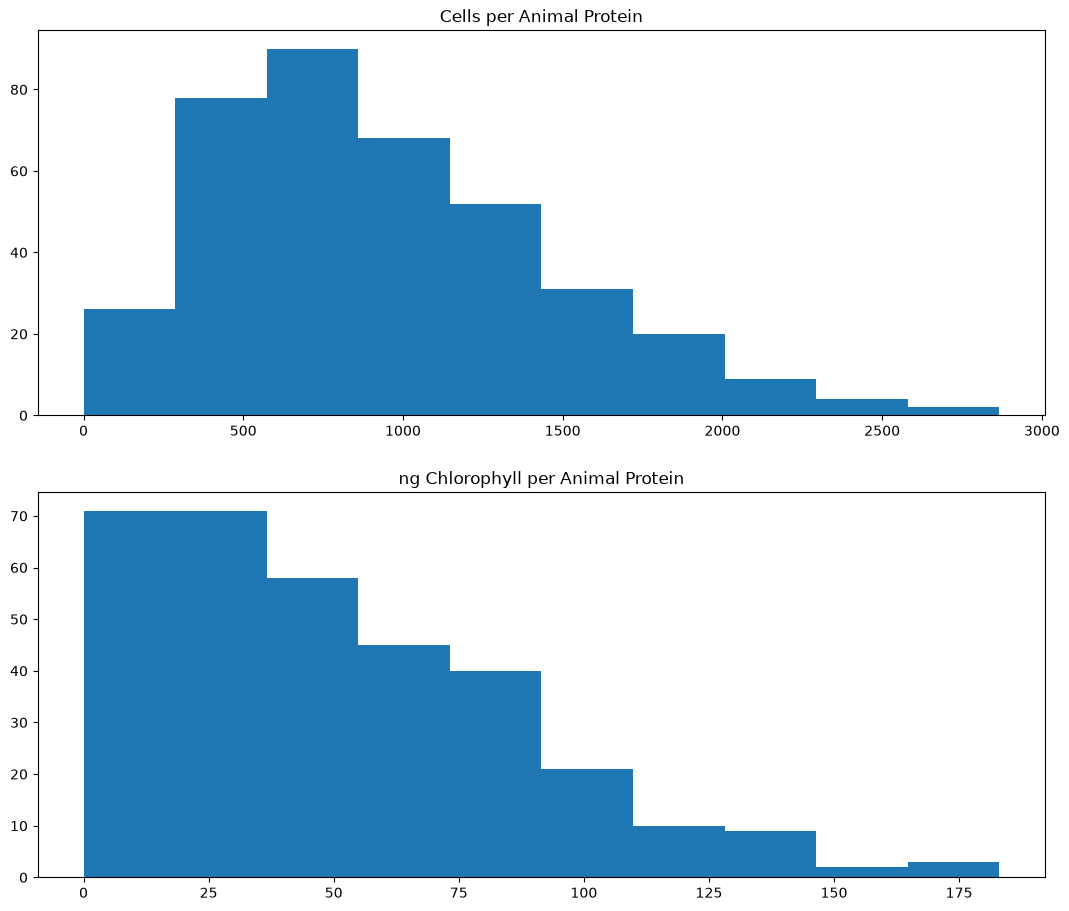

In [5]:
fig, (ax1, ax2)  = plt.subplots(2, 1, sharey=False, figsize=(13,11))

ax1.hist(a_sola_symbiont_data.num_cells_per_ug_protein)
ax1.set(title ='Cells per Animal Protein')

ax2.hist(a_sola_chlorophyll_data.ng_chlorophyll_per_ug_protein)
ax2.set(title ='ng Chlorophyll per Animal Protein')

### Shapiro-Wilk test 
Check if data is normally distributed

p-value interpretation: 
* p > 0.05 means we fail to reject the null hypothesis, suggesting data is likely normal
* p ≤ 0.05 means we reject the null, indicating data significantly deviates from normality, making it non-normal.

Our interpretation of symbiont density and chlorophyll concentration datasets:  
Both dependent variable p-values are significantly below the 0.05 threshold and their skewed histograms suggest both dependent datasets are **non-normal**

In [6]:
print('Testing normalcy of symbiont density data:')
normalcy(a_sola_symbiont_data, 'num_cells_per_ug_protein')
print('')
print('Testing normalcy of chlorophyll concentration data:')
normalcy(a_sola_chlorophyll_data, 'ng_chlorophyll_per_ug_protein')

Testing normalcy of symbiont density data:
ShapiroResult(statistic=np.float64(0.9552970891113842), pvalue=np.float64(2.4638262100598697e-09))

Testing normalcy of chlorophyll concentration data:
ShapiroResult(statistic=np.float64(0.9302689745173908), pvalue=np.float64(2.6438492282361472e-11))


## **Step 3) Generate Figures & Statistics**

## **Bar and line graphs**
* group data by collection group and intertidal zone
* plot mean, SEM error bars
* indicate sample size for each intertidal zone
* plot as both line and bar graphs
* overlay atmospheric river start and end dates according to CW3E

Atmospheric river start and end dates found at: https://cw3e.ucsd.edu/Projects/ARCatalog/catalog.html

We determined line plots to be more appropriate when separating average chlorophyll and symbiont density by tidal zones.

In [7]:
# Load AR events data
ar = pd.read_csv("../abiotic_data/cw3e_ar_events.csv", dtype={"Start_Date": str, "End_Date": str})

### Symbiont Density

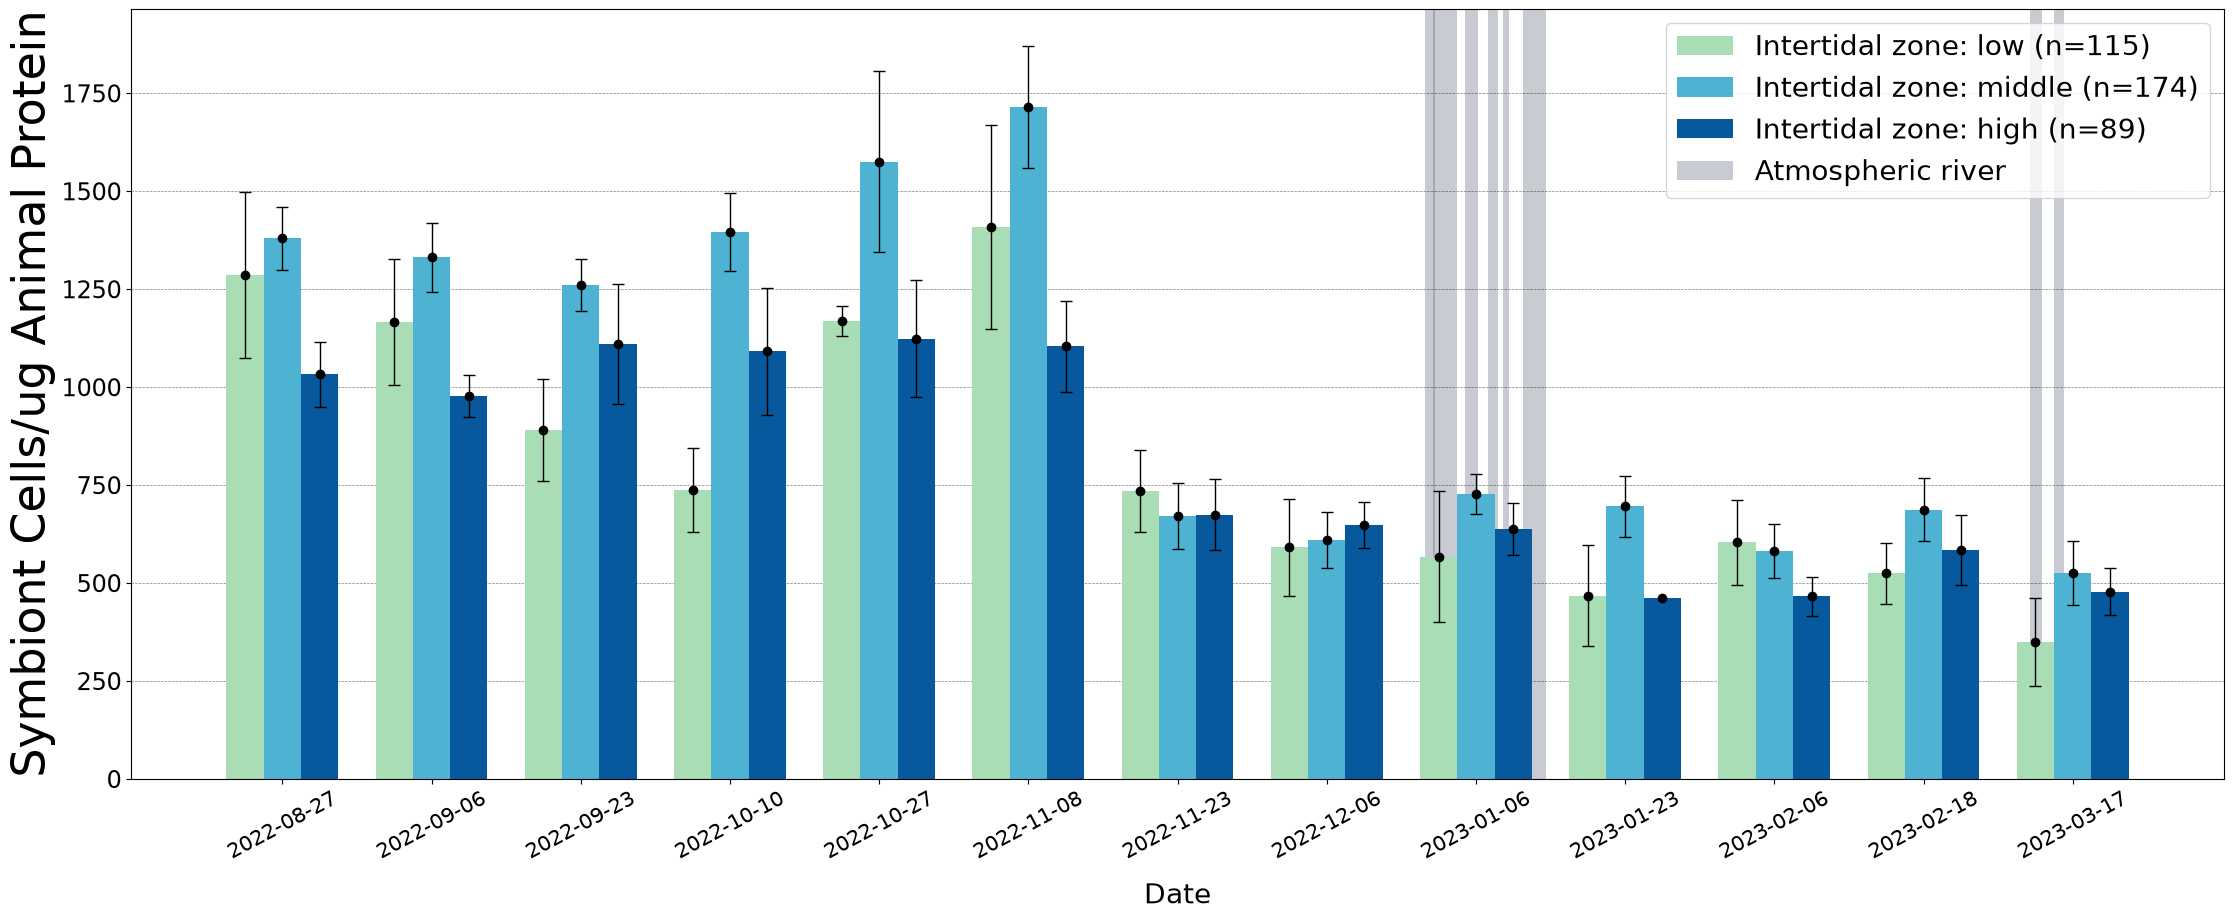

In [8]:
# not used in manuscript  
batch_bar_overlay(a_sola_symbiont_data,
                  'num_cells_per_ug_protein',
                  show_ar=True,
                  ar_data=ar,
                  ar_color="#4a5568",
                  ar_alpha=0.3,
                  ar_label_scale=False, 
                  #save_path='../figures/pre_annotated_figures/symbiont_tidal_bars_.png', 
                  colors=['#a8ddb5', '#4eb3d3', '#08589e'])

Plot saved to ../figures/annotated_figures/fig5_population_symbiont_line_plot.png


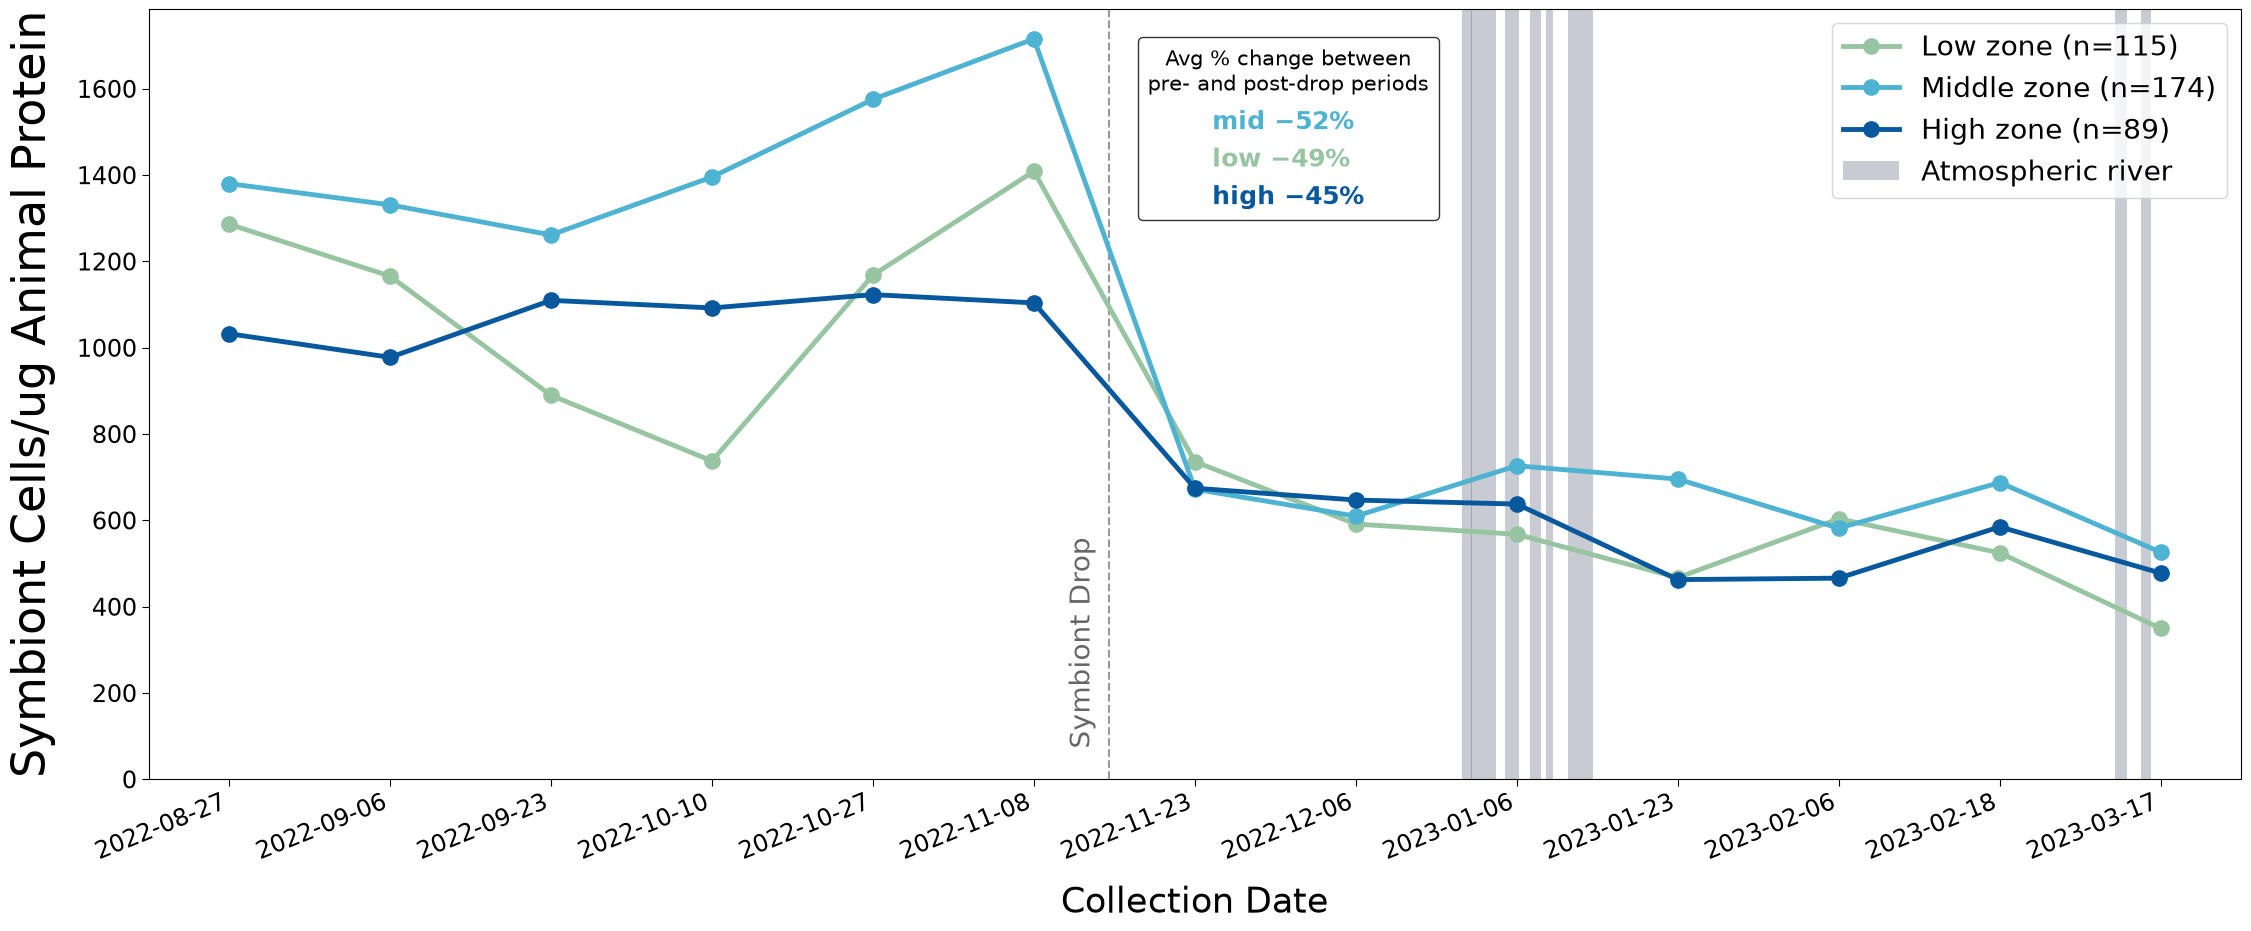

In [14]:
batch_line_plot(a_sola_symbiont_data, 
                  'num_cells_per_ug_protein', 
                  show_ar=True,
                  ar_data=ar,
                  ar_color="#4a5568",
                  ar_alpha=0.3,
                  ar_label_scale=False, 
                  legend_loc='upper right',
                  footnote='',
                  save_path='../figures/annotated_figures/fig5_population_symbiont_line_plot.png', 
                  colors=["#97c5a2", '#4eb3d3', '#08589e'],
                  pct_box_loc=(0.1, 0.98))

### Chlorophyll Concentration

No data found for group 7
No data found for variable ng_chlorophyll_per_ug_protein
No data found for group 7
No data found for variable ng_chlorophyll_per_ug_protein
No data found for group 7
No data found for variable ng_chlorophyll_per_ug_protein


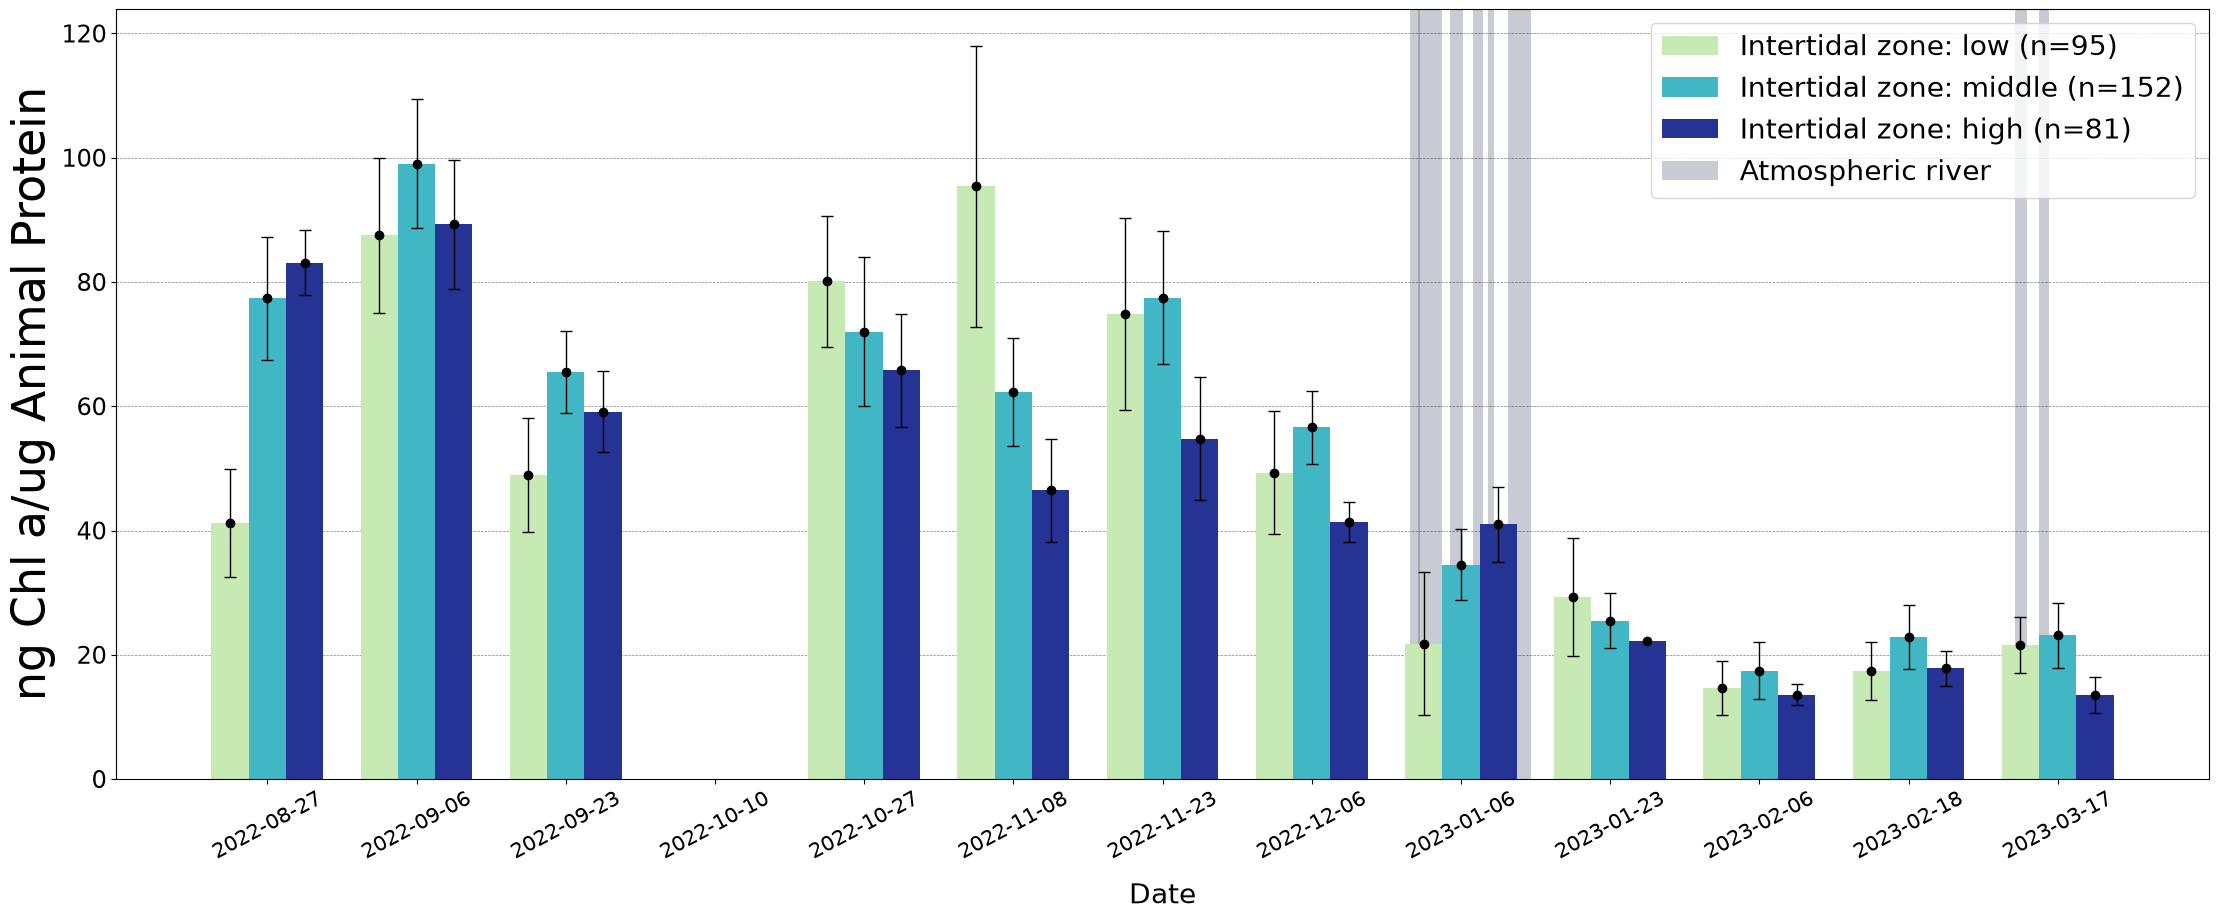

In [10]:
# not used in manuscript
batch_bar_overlay(a_sola_chlorophyll_data, 
                  'ng_chlorophyll_per_ug_protein', 
                  show_ar=True,
                  ar_data=ar,
                  ar_color="#4a5568",
                  ar_alpha=0.3,
                  ar_label_scale=False, 
                  #save_path='../figures/pre_annotated_figures/chlorophyll_tidal_bars.png', 
                  colors=['#c7e9b4', '#41b6c4', '#253494'])

No data found for group 7
No data found for variable ng_chlorophyll_per_ug_protein
No data found for group 7
No data found for variable ng_chlorophyll_per_ug_protein
No data found for group 7
No data found for variable ng_chlorophyll_per_ug_protein
Plot saved to ../figures/annotated_figures/fig7_chl_tidal_zones_line_plot.png


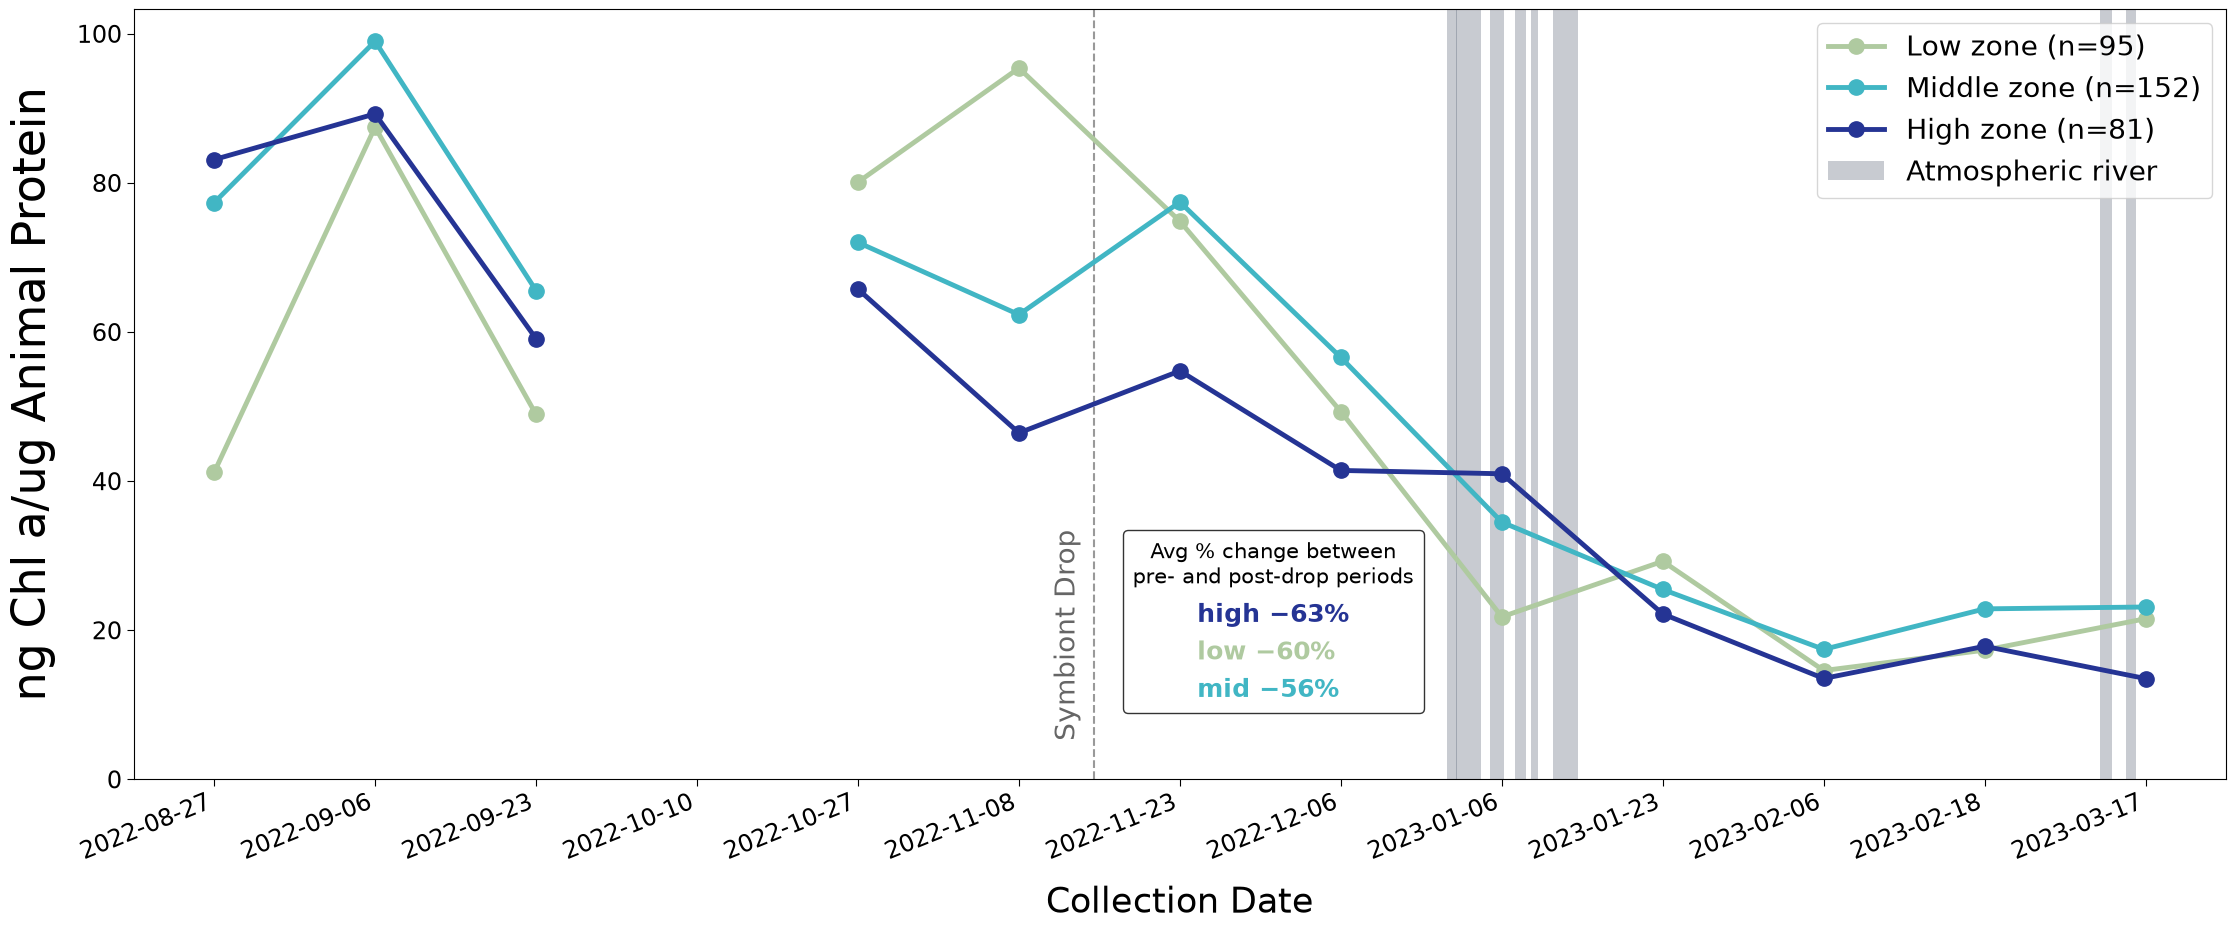

In [19]:
batch_line_plot(a_sola_chlorophyll_data, 
                  'ng_chlorophyll_per_ug_protein', 
                  show_ar=True,
                  ar_data=ar,
                  ar_color="#4a5568",
                  ar_alpha=0.3,
                  ar_label_scale=False, 
                  legend_loc='upper right',
                  footnote='',
                  drop_label='Symbiont Drop',
                  drop_label_y=0.05,
                  save_path='../figures/annotated_figures/fig7_chl_tidal_zones_line_plot.png', 
                  colors=["#afcaa0", '#41b6c4', '#253494'],
                  pct_box_loc=(0.1, 0.34))

## **Box Plots**
Generate box plot figures summarizing data by collection date across all tidal zones over time

### Symbiont Density

Plot saved to ../figures/annotated_figures/fig4_population_symbiont_reduction_box_plot.png


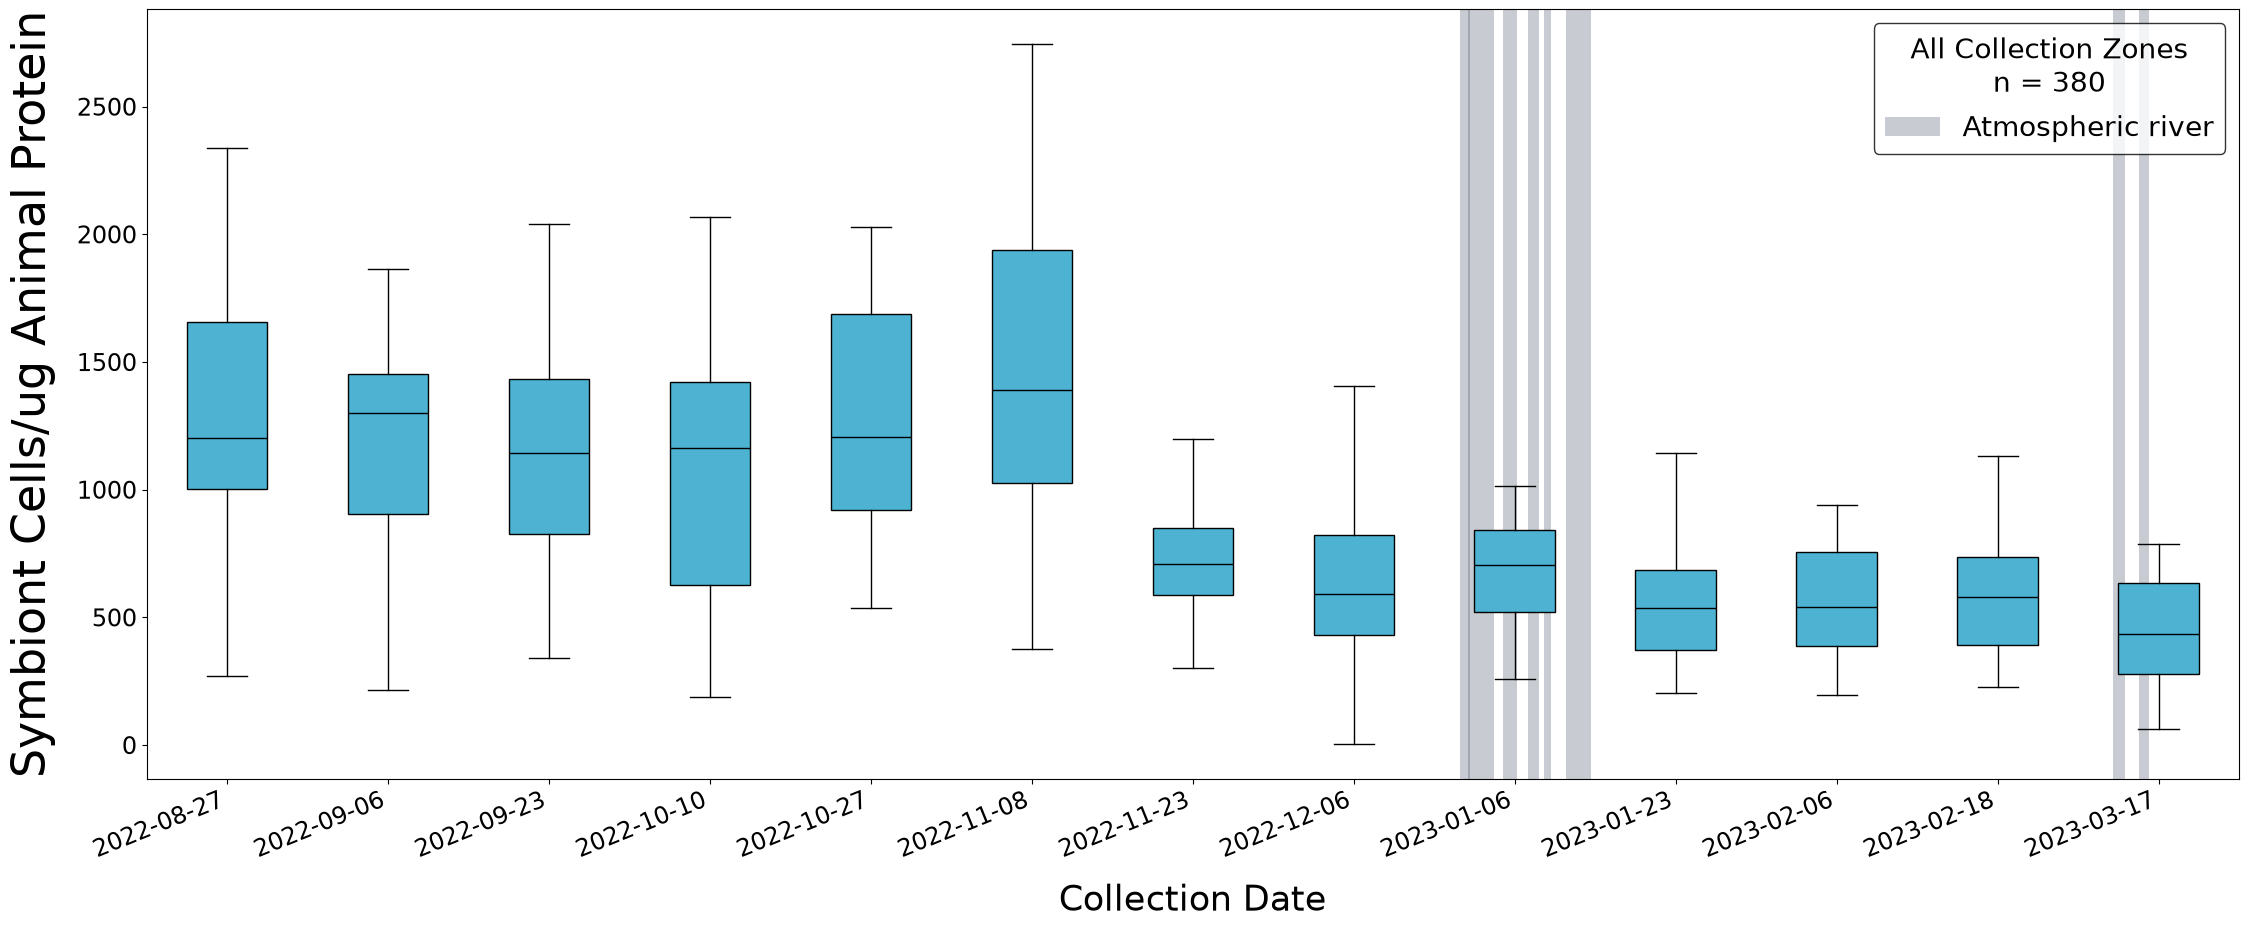

In [12]:
batch_box_plot(a_sola_symbiont_data, 
               'num_cells_per_ug_protein', 
               'Symbiont Cells/ug Animal Protein', 
               zone='', 
               save_path='../figures/annotated_figures/fig4_population_symbiont_reduction_box_plot', 
               box_colors='#4eb3d3',
               show_ar=True,
               ar_data=ar,
               ar_color="#4a5568",
               ar_alpha=0.3,
               legend_loc='upper right'
) 

### Chlorophyll Concentration

No data found for group 7
No data found for batch size 7; leaving it empty.
Plot saved to ../figures/annotated_figures/fig6_population_chlorophyll_reduction_box_plot.png


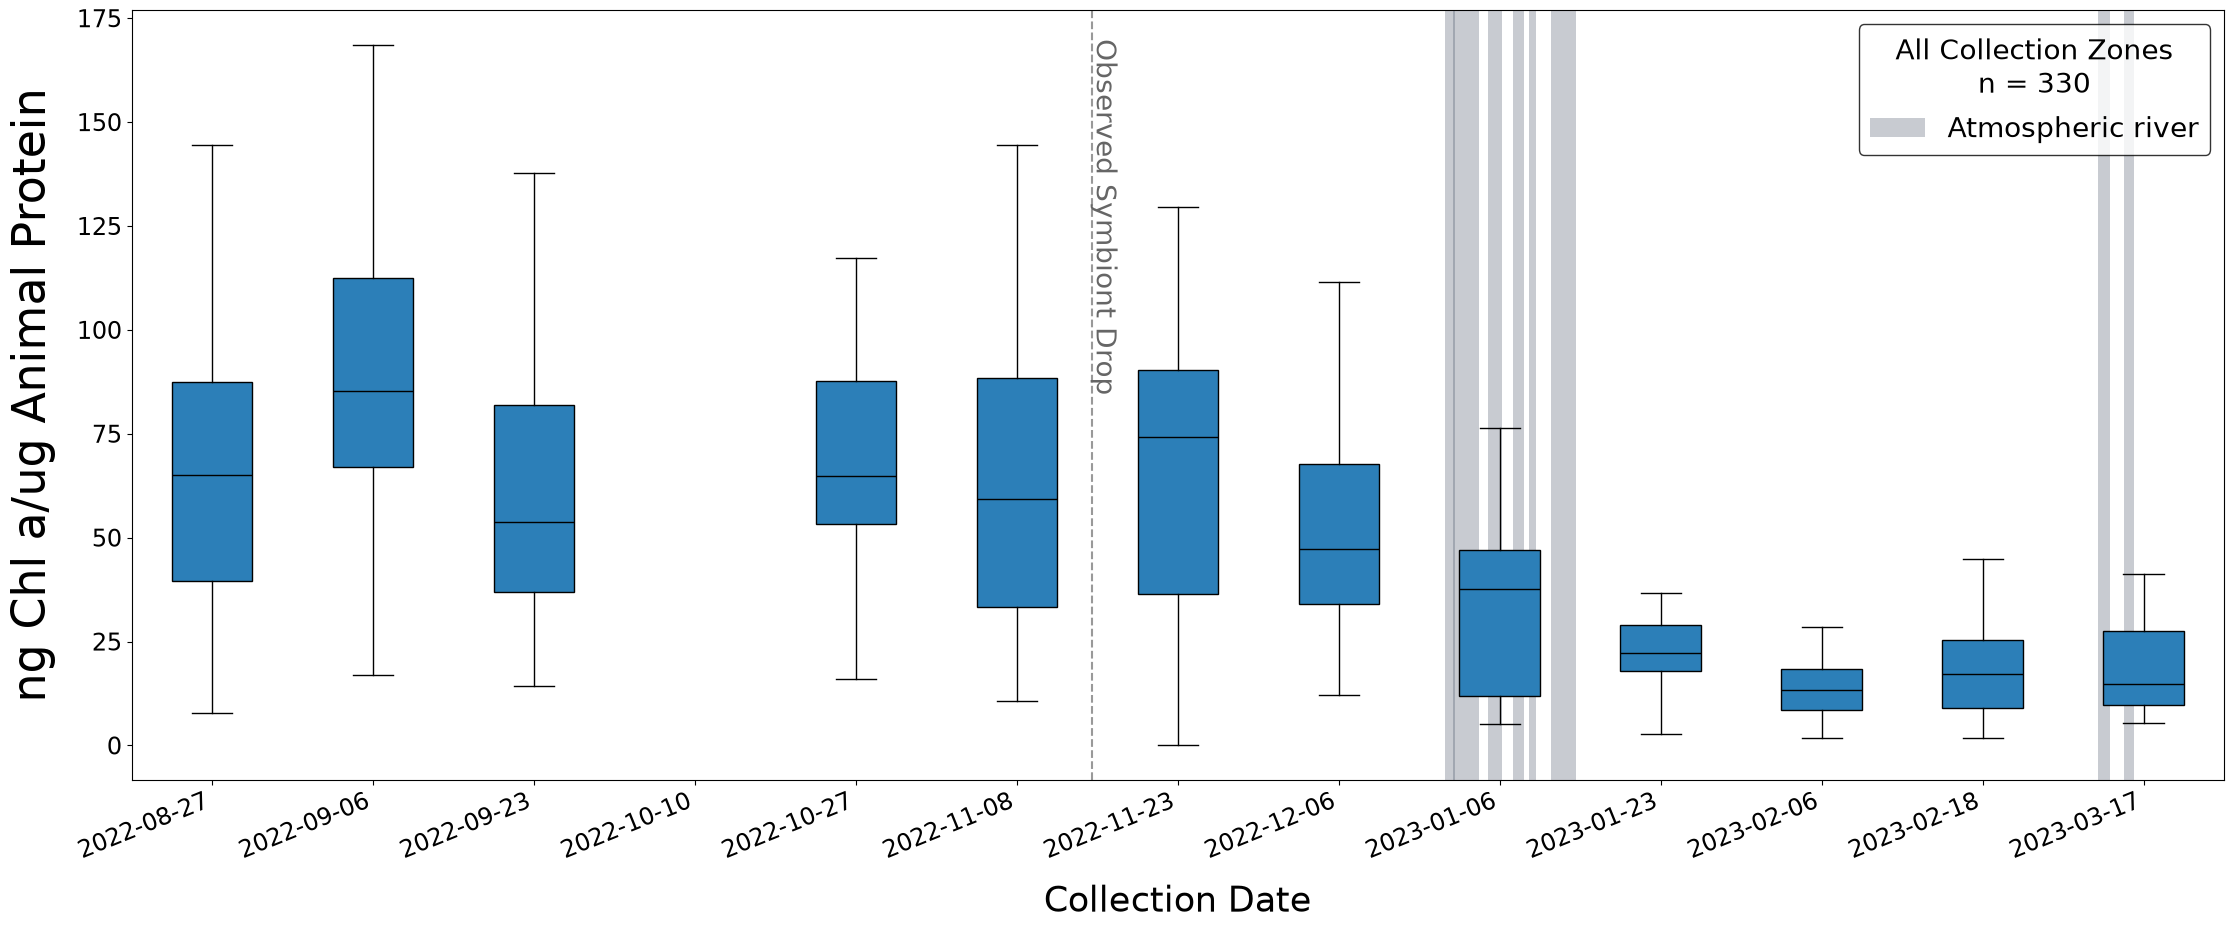

In [13]:
batch_box_plot(a_sola_chlorophyll_data, 
               'ng_chlorophyll_per_ug_protein', 
               'ng Chl a/ug Animal Protein', 
               zone='', 
               save_path='../figures/annotated_figures/fig6_population_chlorophyll_reduction_box_plot',
               box_colors='#2c7fb8',
               show_ar=True,
               ar_data=ar,
               ar_color="#4a5568",
               ar_alpha=0.3,
               ar_label_scale=False,
               legend_loc='upper right',
               show_drop_line=True,
               drop_label_y=0.5,
               drop_label='Observed Symbiont Drop'
)

No data found for group 7
No data found for batch size 7, skipping...
Plot saved to ../figures/annotated_figures/fig6_population_chlorophyll_reduction_box_plot.png


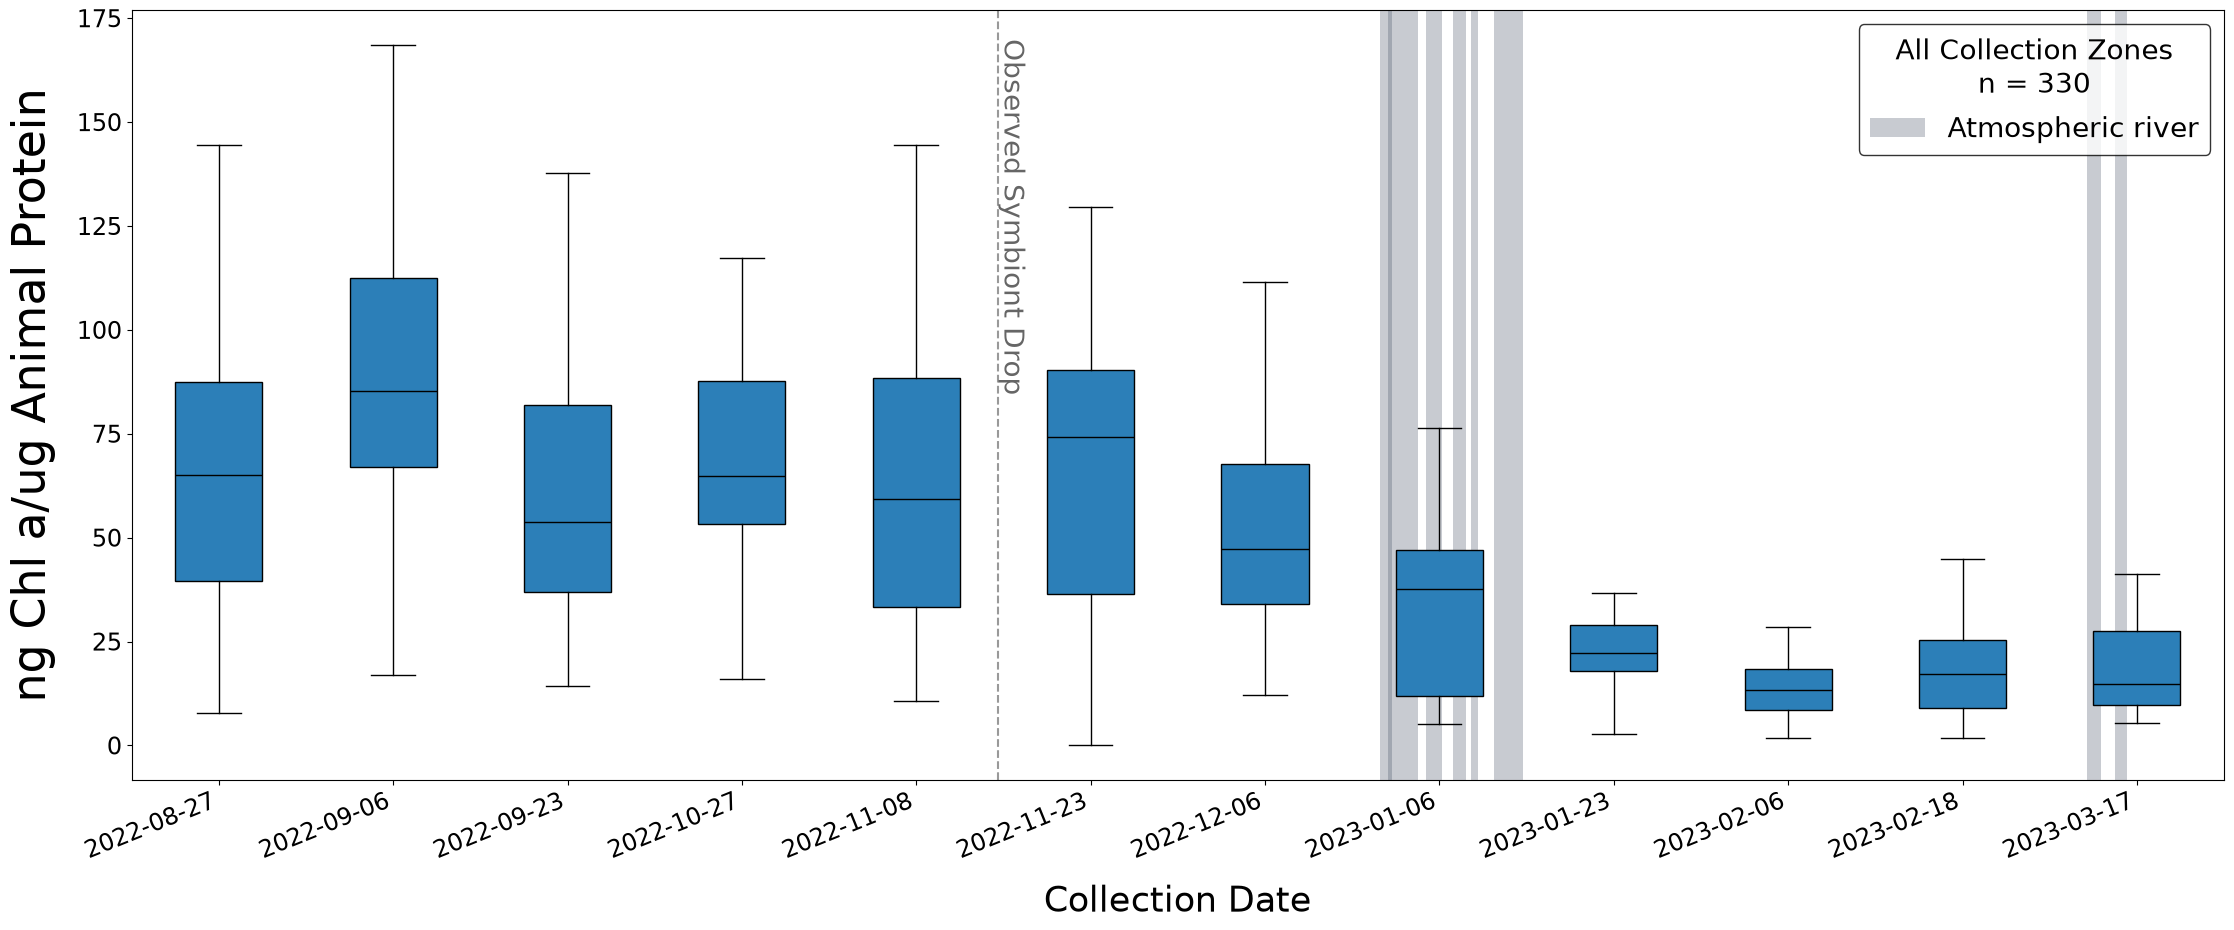

In [29]:
batch_box_plot(a_sola_chlorophyll_data, 
               'ng_chlorophyll_per_ug_protein', 
               'ng Chl a/ug Animal Protein', 
               zone='', 
               save_path='../figures/annotated_figures/fig6_population_chlorophyll_reduction_box_plot',
               box_colors='#2c7fb8',
               show_ar=True,
               ar_data=ar,
               ar_color="#4a5568",
               ar_alpha=0.3,
               ar_label_scale=False,
               legend_loc='upper right',
               show_drop_line=True,
               drop_label_y=0.5,
               drop_label='Observed Symbiont Drop'
)

### Kruskal-Wallis Test
Pre vs post drop observed in the bar graph
* can use individual tidal heights or all

> **Note (post-review update):** Our samples are repeated measures — the same ~35-38 tagged anemones were sampled bimonthly across the season, so treating every tentacle sample as an independent observation violates the independence assumption behind Kruskal-Wallis and Dunn's test, and can understate p-values. The Kruskal-Wallis cells below are kept for reference/comparison only. **The results we report are now from the GEE (Generalized Estimating Equations) models further down**, which use a Gamma family (log link) appropriate for this right-skewed, strictly-positive data and cluster observations by individual anemone (`specimen_id`) to properly account for repeated sampling.

### Symbiont Density

In [ ]:
kruskal_drops(a_sola_symbiont_data, 'num_cells_per_ug_protein', 'all')

### Chlorophyll Concentration

In [ ]:
kruskal_drops(a_sola_chlorophyll_data, 'ng_chlorophyll_per_ug_protein', 'all')

### GEE Test (Repeated-Measures Alternative) — Pre vs. Post Drop
Same pre/post-drop comparison as above, but using a Gamma-family GEE model that clusters repeated samples by individual anemone (`specimen_id`), which correctly accounts for the repeated-sampling design. This replaces `kruskal_drops` for reported inference.

#### Symbiont Density

In [ ]:
symbiont_period_res = gee_period_test(a_sola_symbiont_data, 'num_cells_per_ug_protein', zone='high')

#### Chlorophyll Concentration

In [ ]:
chl_period_res = gee_period_test(a_sola_chlorophyll_data, 'ng_chlorophyll_per_ug_protein', zone='high')

## **Test statistical significance between intertidal zones**

> **Note (post-review update):** As above, the Dunn's post-hoc test cells below treat every tentacle sample as independent, which is not appropriate given the repeated sampling of the same individuals. They are kept for reference/comparison only. **The GEE-based pairwise zone contrasts further down are what we report.**

### Symbiont Density

In [ ]:
data = [a_sola_symbiont_data[a_sola_symbiont_data['intertidal_zone']=="low"]['num_cells_per_ug_protein'],
        a_sola_symbiont_data[a_sola_symbiont_data['intertidal_zone']=="middle"]['num_cells_per_ug_protein'],
        a_sola_symbiont_data[a_sola_symbiont_data['intertidal_zone']=="high"]['num_cells_per_ug_protein']]

# using the posthoc_dunn() function
p_values= sp.posthoc_dunn(data, p_adjust = 'holm')

print(p_values)

### Chlorophyll Concentration

In [ ]:
data = [a_sola_chlorophyll_data[a_sola_chlorophyll_data['intertidal_zone']=="low"]['ng_chlorophyll_per_ug_protein'],
        a_sola_chlorophyll_data[a_sola_chlorophyll_data['intertidal_zone']=="middle"]['ng_chlorophyll_per_ug_protein'],
        a_sola_chlorophyll_data[a_sola_chlorophyll_data['intertidal_zone']=="high"]['ng_chlorophyll_per_ug_protein']]

# using the posthoc_dunn() function
p_values= sp.posthoc_dunn(data, p_adjust = 'holm')

print(p_values)

### GEE Test (Repeated-Measures Alternative) — Intertidal Zone Comparison
Overall zone effect and pairwise contrasts using the same Gamma-family GEE approach, clustered by individual anemone (`specimen_id`), with Holm-adjusted p-values for the pairwise comparisons. This replaces the Dunn's post-hoc test above for reported inference.

#### Symbiont Density

In [ ]:
symbiont_zone_res = gee_zone_test(a_sola_symbiont_data, 'num_cells_per_ug_protein')

In [ ]:
symbiont_zone_pairwise = gee_pairwise_zone_contrasts(a_sola_symbiont_data, 'num_cells_per_ug_protein')
symbiont_zone_pairwise

#### Chlorophyll Concentration

In [ ]:
chl_zone_res = gee_zone_test(a_sola_chlorophyll_data, 'ng_chlorophyll_per_ug_protein')

In [ ]:
chl_zone_pairwise = gee_pairwise_zone_contrasts(a_sola_chlorophyll_data, 'ng_chlorophyll_per_ug_protein')
chl_zone_pairwise

## **Intertidal Zone Box Plot**
Summary box plot(s) that visualize variable mean and SEM grouped for each tidal zone and across time

### Symbiont Density

In [ ]:
# symbiont density
intertidal_box_plot(a_sola_symbiont_data,
                    'num_cells_per_ug_protein',
                    yaxis='Symbiont Cells/ug Animal Protein',
                    title='Tidal Zone on Symbiont Density',
                    save_path='../figures/pre_annotated_figures/symbiont_intertidal_box_plot.png', box_color='#4eb3d3')

### Chlorophyll Concentration

In [ ]:
# chlorophyll concentration
intertidal_box_plot(a_sola_chlorophyll_data,
                    'ng_chlorophyll_per_ug_protein',
                    yaxis='ng Chl a/ug Animal Protein',
                    title='Tidal Zone on Chlorophyll a',
                    save_path='../figures/pre_annotated_figures/chlorophyll_intertidal_box_plot.png',
                    box_color='#2c7fb8')